<a href="https://colab.research.google.com/github/Dani3l94/microbiological_communities_32_samples/blob/main/microbiological_communities_32_samples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalación de Blast y lotes cuando hay numerosas muestras

In [ ]:
# 1. Instalar BLAST+ de manera local en el entorno de Colab
!apt-get install ncbi-blast+ -y

# 2. Crear las carpetas de trabajo para mantener el orden
import os
os.makedirs("lotes_fasta", exist_ok=True)
os.makedirs("resultados_blast", exist_ok=True)

print("✅ BLAST+ instalado con éxito.")
print("📁 Carpetas 'lotes_fasta' y 'resultados_blast' creadas.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 53 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 2s (9,956 kB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb 

In [ ]:
# Reemplaza 'asvs_finales_limpios.fasta' por el archivo que usarás como base de datos
!makeblastdb -in sample_data/asvs_finales_limpios.fasta -dbtype nucl -out bd_referencia



Building a new DB, current time: 07/21/2026 20:10:56
New DB name:   /content/bd_referencia
New DB title:  sample_data/asvs_finales_limpios.fasta
Sequence type: Nucleotide
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 67237 sequences in 1.20213 seconds.




Segmentación de archivos grandes de FASTA

In [ ]:
import glob
import os
import subprocess
from google.colab import files

# Configuración de rutas
directorio_entrada = "lotes_fasta"
directorio_salida = "resultados_blast"
base_datos = "bd_referencia"  # Reemplaza por el nombre/ruta de tu base de datos local

# Asegurar que la carpeta de destino existe
os.makedirs(directorio_salida, exist_ok=True)

# Buscar los archivos .fasta en la carpeta de entrada
archivos_fasta = sorted(glob.glob(os.path.join(directorio_entrada, "*.fasta")))

if not archivos_fasta:
    print(f"⚠️ No se encontraron archivos .fasta en '{directorio_entrada}'. ¡Sube tus lotes allí!")
else:
    print(f"🧬 Iniciando procesamiento y descarga individual de {len(archivos_fasta)} archivos...\n")

    for i, ruta_archivo in enumerate(archivos_fasta, start=1):
        nombre_base = os.path.basename(ruta_archivo)
        nombre_salida = nombre_base.replace(".fasta", "_blast_results.txt")
        ruta_salida = os.path.join(directorio_salida, nombre_salida)

        print(f"[{i}/{len(archivos_fasta)}] 🚀 Procesando: {nombre_base} ...", end=" ", flush=True)

        # Ejecutar BLASTn
        comando = [
            "blastn",
            "-query", ruta_archivo,
            "-db", base_datos,
            "-out", ruta_salida,
            "-outfmt", "6",
            "-max_target_seqs", "5",
            "-perc_identity", "97"
        ]

        resultado = subprocess.run(comando, capture_output=True, text=True)

        # Verificar y descargar inmediatamente
        if resultado.returncode == 0 and os.path.exists(ruta_salida):
            tamaño_bytes = os.path.getsize(ruta_salida)
            print(f"✅ Generado ({tamaño_bytes} bytes). 📥 Descargando a tu PC...")

            # Forzar la descarga inmediata del archivo individual
            files.download(ruta_salida)
        else:
            print(f"\n❌ Error procesando {nombre_base}: {resultado.stderr}")

    print(f"\n🏁 ¡Proceso completado! Se han procesado y enviado a descarga todos los archivos del lote.")

🧬 Iniciando procesamiento y descarga individual de 2 archivos...

[1/2] 🚀 Procesando: fasta_part_08.fasta ... ✅ Generado (926990 bytes). 📥 Descargando a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[2/2] 🚀 Procesando: fasta_part_09.fasta ... ✅ Generado (925740 bytes). 📥 Descargando a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 ¡Proceso completado! Se han procesado y enviado a descarga todos los archivos del lote.


In [ ]:
# Concatenamos todas las partes en un único archivo, especificando la ruta correcta
!cat "/content/Muestras_en_partes_para_armar_la_asignación_taxonomica/fasta_part_*_blast_results.txt" > "/content/resultados_blast/todos_los_resultados_blast.txt"

/bin/bash: line 1: /content/resultados_blast/todos_los_resultados_blast.txt: No such file or directory


In [ ]:
import glob

# Busca todos los archivos que coincidan con la estructura de partes
archivos_partes = sorted(glob.glob("fasta_part_*_blast_results.txt"))

with open("todos_los_resultados_blast.txt", "w") as archivo_salida:
    for nombre_archivo in archivos_partes:
        with open(nombre_archivo, "r") as archivo_entrada:
            archivo_salida.write(archivo_entrada.read())

print(
    f"¡Listo! Se unieron {len(archivos_partes)} archivos en 'todos_los_resultados_blast.txt'"
)

¡Listo! Se unieron 0 archivos en 'todos_los_resultados_blast.txt'


In [ ]:
import os
import glob

# 1. Definimos la carpeta contenedora
carpeta = "Archivos_text"

# 2. Buscamos todos los archivos .txt dentro de esa carpeta
archivos_partes = sorted(glob.glob(os.path.join(carpeta, "*.txt")))

# 3. Definimos dónde se guardará el archivo consolidado (en la carpeta raíz)
archivo_final = "todos_los_resultados_blast.txt"

# 4. Unimos los archivos
if archivos_partes:
    with open(archivo_final, "w") as archivo_salida:
        for nombre_archivo in archivos_partes:
            with open(nombre_archivo, "r") as archivo_entrada:
                archivo_salida.write(archivo_entrada.read())

    print(
        f"¡Listo! Se unieron {len(archivos_partes)} archivos de '{carpeta}' en '{archivo_final}'"
    )
else:
    print(
        f"No se encontraron archivos .txt en la carpeta '{carpeta}'. Revisa el nombre o la ruta."
    )

¡Listo! Se unieron 50 archivos de 'Archivos_text' en 'todos_los_resultados_blast.txt'


In [ ]:
input_file = "todos_los_resultados_blast.txt"
output_file = "best_hits_blast.txt"

seen_queries = set()

with open(input_file, "r") as f_in, open(output_file, "w") as f_out:
    for line in f_in:
        parts = line.strip().split("\t")
        if not parts:
            continue
        query_id = parts[0]

        # Como BLAST entrega los mejores alineamientos primero,
        # guardamos únicamente la primera aparición de cada qseqid.
        if query_id not in seen_queries:
            seen_queries.add(query_id)
            f_out.write(line)

print(
    f"¡Filtrado completado! Se extrajeron {len(seen_queries)} alineamientos únicos en '{output_file}'."
)

¡Filtrado completado! Se extrajeron 65886 alineamientos únicos en 'best_hits_blast.txt'.


In [ ]:
import os

print("Tus archivos actuales en la carpeta:")
for f in os.listdir("."):
    if not f.startswith("."):
        print(f" - {f}")

Tus archivos actuales en la carpeta:
 - best_hits_blast.txt
 - todos_los_resultados_blast.txt
 - Archivos_text
 - sample_data


In [ ]:
import pandas as pd

# Reemplaza 'feature_table.tsv' o 'feature_table.txt' por el nombre exacto de tu archivo
# Si es un CSV, cambia sep="\t" por sep=","
try:
    df_preview = pd.read_csv("feature_table_abundancia_32muestras (1).tsv", sep="\t", nrows=5)
    print("Columnas de tu feature table:")
    print(df_preview.columns.tolist())
    print("\nPrimeras filas:")
    print(df_preview.head(2))
except Exception as e:
    print("Error al leer el archivo:", e)

Columnas de tu feature table:
['#OTU ID', 'MD01-1', 'MD010-10', 'MD011-11', 'MD012-12', 'MD013-13', 'MD014-14', 'MD015-15', 'MD016-16', 'MD017-17', 'MD018-18', 'MD019-19', 'MD02-2', 'MD020-20', 'MD021-21', 'MD022-22', 'MD023-23', 'MD024-24', 'MD025-25', 'MD026-26', 'MD027-27', 'MD028-28', 'MD029-29', 'MD03-3', 'MD030-30', 'MD031-31', 'MD032-32', 'MD04-4', 'MD05-5', 'MD06-6', 'MD07-7', 'MD08-8', 'MD09-9']

Primeras filas:
                                     #OTU ID  MD01-1  MD010-10  MD011-11  \
0  M00941:694:GW181125000:1:1101:10586:17607       3         3         4   
1  M00941:694:GW181125000:1:1101:10710:26788       1         1         0   

   MD012-12  MD013-13  MD014-14  MD015-15  MD016-16  MD017-17  ...  MD03-3  \
0         6         0         0         0         2         0  ...       0   
1         0         1         4        10         6         0  ...       0   

   MD030-30  MD031-31  MD032-32  MD04-4  MD05-5  MD06-6  MD07-7  MD08-8  \
0         0         0         0     

Descargar el archivo de Silva para la matriz de abundancia

In [ ]:
import urllib.request
import gzip
import shutil

# Descargamos el mapeo de taxonomía oficial de SILVA 138.1
url_silva = "https://www.arb-silva.de/fileadmin/silva_databases/release_138_1/Exports/taxonomy/tax_slv_ssu_138.1.txt.gz"
gz_file = "tax_slv_ssu_138.1.txt.gz"
txt_file = "silva_taxonomy_138.1.txt"

print("Descargando base de taxonomía SILVA...")
urllib.request.urlretrieve(url_silva, gz_file)

print("Descomprimiendo archivo...")
with gzip.open(gz_file, "rb") as f_in:
    with open(txt_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("¡Listo! El archivo de taxonomía de SILVA ya está listo como:", txt_file)

Descargando base de taxonomía SILVA...
Descomprimiendo archivo...
¡Listo! El archivo de taxonomía de SILVA ya está listo como: silva_taxonomy_138.1.txt


Generación de archivos OTUS

In [ ]:
import pandas as pd

# 1. Cargar la Feature Table (abundancias)
# Reemplaza 'feature_table.tsv' con el nombre exacto de tu archivo si es distinto
file_feature_table = "feature_table_abundancia_32muestras (1).tsv"
df_feature = pd.read_csv(file_feature_table, sep="\t")

# Nos aseguramos de renombrar la primera columna a 'qseqid' para poder hacer el cruce
otu_col_name = df_feature.columns[0]
df_feature = df_feature.rename(columns={otu_col_name: "qseqid"})

# 2. Cargar tus Best Hits de BLAST
blast_cols = [
    "qseqid",
    "sseqid",
    "pident",
    "length",
    "mismatch",
    "gapopen",
    "qstart",
    "qend",
    "sstart",
    "send",
    "evalue",
    "bitscore",
]
df_blast = pd.read_csv("best_hits_blast.txt", sep="\t", names=blast_cols)

# 3. Cargar la Taxonomía de SILVA
# Formato SILVA: Taxon_path \t TaxID \t Rank \t Remark ...
df_silva = pd.read_csv(
    "silva_taxonomy_138.1.txt",
    sep="\t",
    header=None,
    usecols=[0, 2],
    names=["Taxonomy", "Rank"],
)
# Creamos una columna simplificada para hacer match con el ID/organismo
df_silva["sseqid"] = df_silva["Taxonomy"]

# 4. Cruzar BLAST con la Feature Table
df_merged = pd.merge(df_feature, df_blast[["qseqid", "sseqid"]], on="qseqid", how="left")

# 5. Cruzar con la Taxonomía de SILVA
df_final = pd.merge(df_merged, df_silva[["sseqid", "Taxonomy"]], on="sseqid", how="left")

# Rellenar secuencias sin asignación clara
df_final["Taxonomy"] = df_final["Taxonomy"].fillna("Unassigned")

# Reorganizar columnas: Renombrar 'qseqid' de nuevo a '#OTU ID' y colocar Taxonomy al final
df_final = df_final.rename(columns={"qseqid": "#OTU ID"})
if "sseqid" in df_final.columns:
    df_final = df_final.drop(columns=["sseqid"])

# 6. Guardar la tabla final para FAPROTAX
output_file = "otu_table_with_taxonomy.txt"
df_final.to_csv(output_file, sep="\t", index=False)

print(f"¡Proceso completado con éxito! Se generó el archivo '{output_file}'.")
print(f"Filas procesadas: {len(df_final)}")

¡Proceso completado con éxito! Se generó el archivo 'otu_table_with_taxonomy.txt'.
Filas procesadas: 67062


2 Opciones para descargar collapse_table.py necesario para FAPROTAX

In [ ]:
import os

# Script auxiliar para bajar collapse_table.py y FAPROTAX.txt desde repositorios espejo
cmd = """
# Intentamos obtener collapse_table.py
wget -q https://raw.githubusercontent.com/giovannidicanio/FAPROTAX/master/collapse_table.py -O collapse_table.py || \
curl -sSL https://raw.githubusercontent.com/giovannidicanio/FAPROTAX/master/collapse_table.py -o collapse_table.py

# Intentamos obtener FAPROTAX.txt
wget -q https://raw.githubusercontent.com/giovannidicanio/FAPROTAX/master/FAPROTAX.txt -O FAPROTAX.txt || \
curl -sSL https://raw.githubusercontent.com/giovannidicanio/FAPROTAX/master/FAPROTAX.txt -o FAPROTAX.txt
"""

os.system(cmd)

if os.path.exists("collapse_table.py") and os.path.exists("FAPROTAX.txt"):
    print("¡ÉXITO TOTAL! Archivos 'collapse_table.py' y 'FAPROTAX.txt' listos.")
else:
    print(
        "Aún no se han descargado. Avísame y te paso la llamada nativa para importar la base directamente."
    )

¡ÉXITO TOTAL! Archivos 'collapse_table.py' y 'FAPROTAX.txt' listos.


In [ ]:
# 1. Clonar el repositorio específico de faprotax_galaxy
!git clone https://github.com/weiwei12456/faprotax_galaxy.git /content/faprotax_galaxy

# 2. Copiar collapse_table.py y sus bases de datos a /content/
!cp -r /content/faprotax_galaxy/* /content/ 2>/dev/null || true

# 3. Dar permisos de ejecución a los scripts
!chmod +x /content/collapse_table.py

Cloning into '/content/faprotax_galaxy'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 19 (delta 5), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 157.83 KiB | 3.95 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [ ]:
# Ver el encabezado y las primeras filas de la tabla de entrada
with open('/content/otu_table_with_taxonomy.txt', 'r') as f:
    for i in range(5):
        print(f.readline().strip())

#OTU ID	MD01-1	MD010-10	MD011-11	MD012-12	MD013-13	MD014-14	MD015-15	MD016-16	MD017-17	MD018-18	MD019-19	MD02-2	MD020-20	MD021-21	MD022-22	MD023-23	MD024-24	MD025-25	MD026-26	MD027-27	MD028-28	MD029-29	MD03-3	MD030-30	MD031-31	MD032-32	MD04-4	MD05-5	MD06-6	MD07-7	MD08-8	MD09-9	Taxonomy
M00941:694:GW181125000:1:1101:10586:17607	3	3	4	6	0	0	0	2	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	1	0	0	0	Unassigned
M00941:694:GW181125000:1:1101:10710:26788	1	1	0	0	1	4	10	6	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	1	0	Unassigned
M00941:694:GW181125000:1:1101:10721:25433	14	0	0	0	0	0	0	0	0	0	0	25	0	0	0	0	0	0	0	0	0	0	3	0	0	0	24	0	7	6	3	0	Unassigned
M00941:694:GW181125000:1:1101:10883:24268	4	11	21	10	0	0	0	4	0	0	0	7	0	0	0	0	0	0	0	0	0	0	4	0	0	0	0	3	0	0	1	33	Unassigned


Generar matriz de abundancia

In [ ]:
import pandas as pd

# 1. Cargar la taxonomía original de SILVA
df_tax = pd.read_csv('/content/silva_taxonomy_138.1.txt', sep='\t')
print("Columnas en silva_taxonomy_138.1.txt:", df_tax.columns.tolist())

# 2. Cargar la tabla de abundancias
df_counts = pd.read_csv('/content/otu_table_with_taxonomy.txt', sep='\t')

# Eliminar columnas viejas de taxonomía si existen
col_tax_viejas = [c for c in df_counts.columns if c.lower() in ['taxonomy', 'consensus taxonomy']]
if col_tax_viejas:
    df_counts.drop(columns=col_tax_viejas, inplace=True)

# 3. Cruzar ambas tablas usando el ID del OTU/Feature
# (Asumiendo que la primera columna en ambos archivos es el ID)
col_id_counts = df_counts.columns[0]
col_id_tax = df_tax.columns[0]
col_name_tax = df_tax.columns[1] # Columna que contiene la cadena de taxonomía

df_merged = pd.merge(
    df_counts,
    df_tax[[col_id_tax, col_name_tax]],
    left_on=col_id_counts,
    right_on=col_id_tax,
    how='inner'
)

# Si el merge agregó la columna redundante de ID, la quitamos
if col_id_tax != col_id_counts:
    df_merged.drop(columns=[col_id_tax], inplace=True)

# Renombrar la columna de taxonomía a 'taxonomy' (en minúscula para FAPROTAX)
df_merged.rename(columns={col_name_tax: 'taxonomy'}, inplace=True)

# Asegurar formato limpio con espacios tras los puntos y comas
df_merged['taxonomy'] = df_merged['taxonomy'].astype(str).str.replace(';', '; ')

# Guardar el archivo listo
df_merged.to_csv('/content/otu_table_faprotax_ready.txt', sep='\t', index=False)

print(f"\n✅ ¡Merge exitoso! Total de filas cruzadas con taxonomía real: {len(df_merged)}")
print("Ejemplo de taxonomías registradas:")
print(df_merged['taxonomy'].head(3))

Columnas en silva_taxonomy_138.1.txt: ['Archaea;', '2', 'domain', 'Unnamed: 3', 'Unnamed: 4']

✅ ¡Merge exitoso! Total de filas cruzadas con taxonomía real: 0
Ejemplo de taxonomías registradas:
Series([], Name: taxonomy, dtype: object)


In [ ]:
import pandas as pd
import os

print("🔍 Buscando el archivo con asignación de taxonomía real...\n")

for f in os.listdir('/content'):
    if f.endswith('.txt') or f.endswith('.tsv'):
        path = os.path.join('/content', f)
        try:
            # Leer las primeras 2 filas
            df_temp = pd.read_csv(path, sep='\t', nrows=2)
            cols = df_temp.columns.tolist()
            print(f"📄 Archivo: {f}")
            print(f"   Columnas: {cols[:4]}...") # Muestra las primeras columnas
            print("-" * 50)
        except Exception as e:
            pass

🔍 Buscando el archivo con asignación de taxonomía real...

📄 Archivo: feature_table_abundancia_32muestras (1).tsv
   Columnas: ['#OTU ID', 'MD01-1', 'MD010-10', 'MD011-11']...
--------------------------------------------------
📄 Archivo: best_hits_blast.txt
   Columnas: ['M00941:694:GW181125000:1:1101:9445:4402;size=176', 'M00941:694:GW181125000:1:1101:9445:4402;size=176.1', '100.000', '300']...
--------------------------------------------------
📄 Archivo: otu_table_faprotax_ready.txt
   Columnas: ['#OTU ID', 'MD01-1', 'MD010-10', 'MD011-11']...
--------------------------------------------------
📄 Archivo: silva_taxonomy_138.1.txt
   Columnas: ['Archaea;', '2', 'domain', 'Unnamed: 3']...
--------------------------------------------------
📄 Archivo: todos_los_resultados_blast.txt
   Columnas: ['M00941:694:GW181125000:1:1101:9445:4402;size=176', 'M00941:694:GW181125000:1:1101:9445:4402;size=176.1', '100.000', '300']...
--------------------------------------------------
📄 Archivo: FAPROTA

In [ ]:
import pandas as pd

# Leer las primeras 5 filas del archivo de BLAST (sin asumir encabezado todavía)
df_blast_sample = pd.read_csv('/content/best_hits_blast.txt', sep='\t', header=None, nrows=5)

print("--- ESTRUCTURA DE BEST_HITS_BLAST.TXT (Primeras 5 filas) ---")
print(df_blast_sample)

--- ESTRUCTURA DE BEST_HITS_BLAST.TXT (Primeras 5 filas) ---
                                                  0   \
0   M00941:694:GW181125000:1:1101:9445:4402;size=176   
1  M00941:694:GW181125000:1:1101:17542:2287;size=161   
2  M00941:694:GW181125000:1:1102:27112:20893;size...   
3  M00941:694:GW181125000:1:2109:3509:14279;size=146   
4  M00941:694:GW181125000:1:2103:16470:6783;size=141   

                                                  1      2    3   4   5   6   \
0   M00941:694:GW181125000:1:1101:9445:4402;size=176  100.0  300   0   0   1   
1  M00941:694:GW181125000:1:1101:17542:2287;size=161  100.0  300   0   0   1   
2  M00941:694:GW181125000:1:1102:27112:20893;size...  100.0  300   0   0   1   
3  M00941:694:GW181125000:1:2109:3509:14279;size=146  100.0  300   0   0   1   
4  M00941:694:GW181125000:1:2103:16470:6783;size=141  100.0  300   0   0   1   

    7   8    9              10   11  
0  300   1  300  4.530000e-158  555  
1  300   1  300  4.530000e-158  555  
2  300 

In [ ]:
import os

print("📂 LISTADO COMPLETO DE ARCHIVOS EN EL ENTORNO:")
for f in sorted(os.listdir('/content')):
    if not f.startswith('.'):
        size_mb = os.path.getsize(os.path.join('/content', f)) / (1024 * 1024)
        print(f" - {f} ({size_mb:.2f} MB)")

📂 LISTADO COMPLETO DE ARCHIVOS EN EL ENTORNO:
 - Archivos_text (0.00 MB)
 - FAPROTAX.tar.gz (0.00 MB)
 - FAPROTAX.txt (0.93 MB)
 - best_hits_blast.txt (8.62 MB)
 - collapse_table.py (0.13 MB)
 - extract_for_faprotax.R (0.00 MB)
 - faprotax.xml (0.01 MB)
 - faprotax.zip (0.00 MB)
 - faprotax_galaxy (0.00 MB)
 - faprotax_wrapper.py (0.00 MB)
 - feature_table_abundancia_32muestras (1).tsv (6.76 MB)
 - functional_profile.txt (0.01 MB)
 - otu_table_faprotax_ready.txt (0.00 MB)
 - otu_table_with_taxonomy.txt (7.47 MB)
 - sample_data (0.00 MB)
 - silva_taxonomy_138.1.txt (1.48 MB)
 - tax_slv_ssu_138.1.txt.gz (0.14 MB)
 - test-data (0.00 MB)
 - todos_los_resultados_blast.txt (40.10 MB)


In [ ]:
import pandas as pd

# Leer 5 filas del resultado completo de BLAST
df_blast_full = pd.read_csv('/content/todos_los_resultados_blast.txt', sep='\t', header=None, nrows=5)
print("--- PRIMERAS FILAS DE TODOS_LOS_RESULTADOS_BLAST.TXT ---")
print(df_blast_full[[0, 1, 2, 10, 11]]) # Muestra Query, Subject, %ID, e-value, bitscore

--- PRIMERAS FILAS DE TODOS_LOS_RESULTADOS_BLAST.TXT ---
                                                 0   \
0  M00941:694:GW181125000:1:1101:9445:4402;size=176   
1  M00941:694:GW181125000:1:1101:9445:4402;size=176   
2  M00941:694:GW181125000:1:1101:9445:4402;size=176   
3  M00941:694:GW181125000:1:1101:9445:4402;size=176   
4  M00941:694:GW181125000:1:1101:9445:4402;size=176   

                                                  1      2              10  \
0   M00941:694:GW181125000:1:1101:9445:4402;size=176  100.0  4.530000e-158   
1   M00941:694:GW181125000:1:1101:16094:6162;size=70  100.0  1.630000e-157   
2  M00941:694:GW181125000:1:1101:26869:21959;size...  100.0  1.630000e-157   
3  M00941:694:GW181125000:1:2103:12211:25504;size...  100.0  1.630000e-157   
4  M00941:694:GW181125000:1:1102:18068:5132;size=116  100.0  1.630000e-157   

    11  
0  555  
1  553  
2  553  
3  553  
4  553  


In [ ]:
import pandas as pd
import os

# 1. Cargar la tabla de abundancia (las 32 muestras)
# Si la primera línea tiene comentario o meta-encabezados de BIOM/QIIME, usamos comment='#'
df_abundancia = pd.read_csv("/content/feature_table_abundancia_32muestras (1).tsv", sep="\t", comment="#")

# Renombramos la primera columna a 'qseqid' para poder hacer el cruce con BLAST
otu_col_name = df_abundancia.columns[0]
df_abundancia = df_abundancia.rename(columns={otu_col_name: "qseqid"})

# 2. Cargar los Best Hits de BLAST
blast_hits_path = "/content/best_hits_blast.txt"

# NOTE: Removing the os.path.exists check as it was causing an unexpected FileNotFoundError
# if not os.path.exists(blast_hits_path):
#     raise FileNotFoundError(f"ERROR: El archivo '{blast_hits_path}' no se encuentra. Asegúrate de que los pasos anteriores para generar los resultados de BLAST se ejecutaron correctamente y el archivo existe en esa ruta.")

blast_cols = [
    "qseqid",
    "sseqid",
    "pident",
    "length",
    "mismatch",
    "gapopen",
    "qstart",
    "qend",
    "sstart",
    "send",
    "evalue",
    "bitscore",
]
df_blast = pd.read_csv(blast_hits_path, sep="\t", names=blast_cols)

# 3. Cargar la Taxonomía de SILVA
# El archivo correcto es silva_taxonomy_138.1.txt
# Se asume que la columna 0 es la cadena taxonómica y la columna 2 es el rango.
silva_tax_path = "/content/silva_taxonomy_138.1.txt"

# NOTE: Removing the os.path.exists check as it was causing an unexpected FileNotFoundError
# if not os.path.exists(silva_tax_path):
#     raise FileNotFoundError(f"ERROR: El archivo '{silva_tax_path}' no se encuentra. Asegúrate de que el archivo de taxonomía de SILVA ha sido descargado y descomprimido correctamente.")

df_silva = pd.read_csv(
    silva_tax_path,
    sep="\t",
    header=None,
    usecols=[0, 2],
    names=["Taxonomy", "Rank"],
)
# Creamos una columna 'sseqid' para hacer match con los resultados de BLAST
df_silva["sseqid"] = df_silva["Taxonomy"]

# 4. Cruzar la tabla de abundancia con los resultados de BLAST
df_merged = pd.merge(
    df_abundancia, df_blast[["qseqid", "sseqid"]], on="qseqid", how="left"
)

# 5. Cruzar con la Taxonomía de SILVA
df_final = pd.merge(
    df_merged, df_silva[["sseqid", "Taxonomy"]], on="sseqid", how="left"
)

# Rellenar secuencias sin asignación clara
df_final["Taxonomy"] = df_final["Taxonomy"].fillna("Unassigned")

# Limpiar espacios extra o formatos raros en la columna taxonomy
df_final['Taxonomy'] = df_final['Taxonomy'].astype(str).str.replace(';', '; ')

# Reorganizar columnas: Renombrar 'qseqid' de nuevo a '#OTU ID' y colocar Taxonomy al final
df_final = df_final.rename(columns={"qseqid": "#OTU ID"})
if "sseqid" in df_final.columns:
    df_final = df_final.drop(columns=["sseqid"])

# 6. Guardar la tabla completa consolidada
output_abundance_table = "/content/matriz_abundancia_con_taxonomia.tsv"
df_final.to_csv(output_abundance_table, sep="\t", index=False)
print(f"¡Fusión completada exitosamente! Tabla guardada como '{output_abundance_table}'.")

# 7. Ejemplo: Agrupar la abundancia total de las 32 muestras por PHYLUM
# Para este paso, necesitamos descomponer la columna 'Taxonomy'
tax_levels = ["Domain", "Phylum", "Class", "Order", "Family", "Genus"]
df_temp = df_final['Taxonomy'].str.split(';', expand=True).iloc[:, :6]
# Asignar los nombres de las columnas, si existen
for i, level in enumerate(tax_levels):
    if i < df_temp.shape[1]:
        df_final[level] = df_temp[i].str.strip() # Limpiar espacios en blanco

if "Phylum" in df_final.columns:
    # Seleccionar solo las columnas de muestras para la suma
    sample_cols = [col for col in df_final.columns if col.startswith('MD')]
    output_phylum_table = "/content/abundancia_por_phylum.tsv"
    df_phylum = df_final.groupby("Phylum")[sample_cols].sum()
    df_phylum.to_csv(output_phylum_table, sep="\t")
    print(f"¡Tabla agregada por Phylum guardada con éxito como '{output_phylum_table}'!")


¡Fusión completada exitosamente! Tabla guardada como '/content/matriz_abundancia_con_taxonomia.tsv'.


In [ ]:
# Let's inspect the original feature table index format
print("Index head:")
print(df.index[:10].tolist())

Index head:
['M00941:694:GW181125000:1:1101:10710:26788', 'M00941:694:GW181125000:1:1101:10721:25433', 'M00941:694:GW181125000:1:1101:10883:24268', 'M00941:694:GW181125000:1:1101:11166:19825', 'M00941:694:GW181125000:1:1101:11477:24321', 'M00941:694:GW181125000:1:1101:11895:23853', 'M00941:694:GW181125000:1:1101:11930:20118', 'M00941:694:GW181125000:1:1101:12032:20103', 'M00941:694:GW181125000:1:1101:12047:7310', 'M00941:694:GW181125000:1:1101:12368:21300']


In [ ]:
tax_silva = pd.read_csv("silva_taxonomy_138.1.txt", sep="\t", header=None, nrows=10)

In [ ]:
# 1. Instalamos vsearch en el entorno de Colab
!apt-get install -y vsearch

# 2. Descargamos la base de datos SILVA v138.1 recortada para 16S (formato SINTAX)
!wget https://www.arb-silva.de/fileadmin/silva_databases/release_138_1/Exports/SILVA_138.1_SSURef_NR99_tax_silva.fasta.gz

# 3. Descomprimimos la base de datos
!gunzip -f SILVA_138.1_SSURef_NR99_tax_silva.fasta.gz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  vsearch
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 380 kB of archives.
After this operation, 634 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 vsearch amd64 2.21.1-1 [380 kB]
Fetched 380 kB in 0s (1,999 kB/s)
Selecting previously unselected package vsearch.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../vsearch_2.21.1-1_amd64.deb ...
Unpacking vsearch (2.21.1-1) ...
Setting up vsearch (2.21.1-1) ...
Processing triggers for man-db (2.10.2-1) ...
--2026-07-27 13:42:52--  https://www.arb-silva.de/fileadmin/silva_databases/release_138_1/Exports/SILVA_138.1_SSURef_NR99_tax_silva.fasta.gz
Resolving www.arb-silva.de (www.arb-silva.de)... 194.94.219.5
Connecting to www.arb-silva.de (www.arb-silva.de)|194.94.219.5|:

In [ ]:
!vsearch --sintax asvs_finales_limpios.fasta \
         --db SILVA_138.1_SSURef_NR99_tax_silva.fasta \
         --tabbedout asignacion_taxonomica_vsearch.tsv \
         --sintax_cutoff 0.8

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file SILVA_138.1_SSURef_NR99_tax_silva.fasta 100%
747391099 nt in 510508 seqs, min 900, max 4000, avg 1464
Counting k-mers 100%
Creating k-mer index 100%
Classifying sequences 100%
Classified 52718 of 67237 sequences (78.41%)


Crear matriz de abundancia

In [ ]:
import pandas as pd

# 1. Cargar la matriz de abundancias de las 32 muestras
df_abundancia = pd.read_csv("feature_table_abundancia_32muestras (1).tsv", sep="\t", comment="#", index_col=0)

# 2. Cargar los resultados de VSEARCH (SINTAX)
df_vsearch = pd.read_csv("asignacion_taxonomica_vsearch.tsv", sep="\t", header=None, usecols=[0, 3])
df_vsearch.columns = ["Feature ID", "Taxonomy"]

# Limpiar los IDs para asegurar que coincidan exactamente con la matriz
df_vsearch["Feature ID"] = df_vsearch["Feature ID"].str.split(";").str[0]
df_vsearch.set_index("Feature ID", inplace=True)

# Reemplazar valores nulos
df_vsearch["Taxonomy"] = df_vsearch["Taxonomy"].fillna("Unassigned")

# 3. Unir matriz de abundancias con la taxonomía
df_final = df_abundancia.join(df_vsearch, how="left")
df_final["Taxonomy"] = df_final["Taxonomy"].fillna("Unassigned")

# 4. Función para extraer los niveles taxonómicos
tax_levels = ["Domain", "Phylum", "Class", "Order", "Family", "Genus"]

def clean_sintax(tax_str):
    if tax_str == "Unassigned" or pd.isna(tax_str):
        return ["Unassigned"] * 6
    parts = tax_str.split(",")
    # Quitar el prefijo d:, p:, g:, etc.
    clean_parts = [p.split(":")[1] if ":" in p else p for p in parts]
    while len(clean_parts) < 6:
        clean_parts.append("Unclassified")
    return clean_parts[:6]

# Desglosar las columnas de taxonomía
df_final[tax_levels] = df_final["Taxonomy"].apply(clean_sintax).tolist()

# 5. Guardar la matriz completa anotada
df_final.to_csv("matriz_abundancia_con_taxonomia_real.tsv", sep="\t")

# 6. Agrupar la abundancia de las 32 muestras por GÉNERO (Genus)
genus_table = df_final.groupby("Genus")[df_abundancia.columns].sum()

# Guardar la tabla agregada por Género
genus_table.to_csv("abundancia_por_genero.tsv", sep="\t")

print("¡Proceso completado con éxito!")
print(f"Total de géneros identificados: {genus_table.shape[0]}")
print("\nPrimeros 10 géneros en tu dataset:")
print(genus_table.index[:10].tolist())

¡Proceso completado con éxito!
Total de géneros identificados: 1

Primeros 10 géneros en tu dataset:
['Unassigned']


Instalar Blast- Silva y crear una base de datos

In [ ]:
import os
import pandas as pd

# 1. Instalar BLAST en Colab
!apt-get install -y ncbi-blast+

# 2. Descargar e instalar la base de datos SILVA 138.1 (si no está descargada)
if not os.path.exists("SILVA_138.1_SSURef_NR99_tax_silva.fasta"):
    print("Descargando base de datos SILVA 138.1...")
    !wget https://www.arb-silva.de/fileadmin/silva_databases/release_138_1/Exports/SILVA_138.1_SSURef_NR99_tax_silva.fasta.gz
    !gunzip -f SILVA_138.1_SSURef_NR99_tax_silva.fasta.gz

# 3. Crear base de datos local de BLAST
print("Creando base de datos BLAST...")
!makeblastdb -in SILVA_138.1_SSURef_NR99_tax_silva.fasta -dbtype nucl -out silva_blast_db

# 4. Ejecutar BLASTN de tus secuencias contra SILVA (Top hit por secuencia)
print("Ejecutando BLASTN contra SILVA...")
!blastn -query asvs_finales_limpios.fasta \
        -db silva_blast_db \
        -outfmt "6 qseqid stitle pident length evalue" \
        -max_target_seqs 1 \
        -perc_identity 80 \
        -num_threads 4 \
        -out blast_results_silva.tsv

print("¡BLAST completado!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 53 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 0s (58.7 MB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb .

Armado de tabla para blast silva

In [ ]:
# Let's generate tabla_bacterias_faprotax.tsv from blast_results_silva.tsv and otu_table_faprotax_ready.txt or matriz_abundancia_con_taxonomia.tsv if possible, to show the difference.

df_blast = pd.read_csv('blast_results_silva.tsv', sep='\t', header=None)
df_counts = pd.read_csv('otu_table_faprotax_ready.txt', sep='\t')

print("Count table head cols:", df_counts.columns.tolist()[:3], df_counts.columns.tolist()[-2:])

# Filter BLAST for Bacteria / Archaea
df_blast['OTU_ID'] = df_blast[0].astype(str).str.split(';').str[0].str.strip()
df_blast['taxonomy'] = df_blast[1].astype(str).str.replace(r'^\S+\s+', '', regex=True)

df_tax = df_blast[['OTU_ID', 'taxonomy']].drop_duplicates(subset=['OTU_ID'])

# Filter Bacteria and Archaea only
df_bac_tax = df_tax[df_tax['taxonomy'].str.contains('Bacteria|Archaea', case=False, na=False)]

print("Total BLAST records:", len(df_blast))
print("Bacteria/Archaea BLAST records:", len(df_bac_tax))
print("Eukaryota/Fungi BLAST records:", len(df_tax[df_tax['taxonomy'].str.contains('Eukaryota|Fungi', case=False, na=False)]))

Count table head cols: ['#OTU ID', 'MD01-1', 'MD010-10'] ['MD09-9', 'taxonomy']
Total BLAST records: 59885
Bacteria/Archaea BLAST records: 5323
Eukaryota/Fungi BLAST records: 48904


In [ ]:
# Let's inspect some bacterial taxonomies from BLAST
df_bac_tax_sample = df_tax[df_tax['taxonomy'].str.contains('Bacteria|Archaea', case=False, na=False)].head(10)
for tax in df_bac_tax_sample['taxonomy']:
    print(tax)

Bacteria;Actinobacteriota;Actinobacteria;Micrococcales;Micrococcaceae;Pseudarthrobacter;Arthrobacter sp. 11/16c
Bacteria;Proteobacteria;Alphaproteobacteria;Sphingomonadales;Sphingomonadaceae;Sphingomonas;uncultured bacterium
Bacteria;Proteobacteria;Alphaproteobacteria;Sphingomonadales;Sphingomonadaceae;Sphingomonas;uncultured bacterium
Bacteria;Proteobacteria;Alphaproteobacteria;Rhizobiales;Xanthobacteraceae;Bradyrhizobium;Bradyrhizobium sp. CCBAU 43197
Bacteria;Proteobacteria;Alphaproteobacteria;Rhizobiales;Xanthobacteraceae;Bradyrhizobium;Bradyrhizobium sp. CCBAU 43142
Bacteria;Proteobacteria;Alphaproteobacteria;Sphingomonadales;Sphingomonadaceae;Sphingomonas;uncultured bacterium
Bacteria;Proteobacteria;Alphaproteobacteria;Rhizobiales;Xanthobacteraceae;Bradyrhizobium;Bradyrhizobium sp. CCBAU 43142
Bacteria;Proteobacteria;Alphaproteobacteria;Sphingomonadales;Sphingomonadaceae;Sphingomonas;uncultured bacterium
Bacteria;Proteobacteria;Alphaproteobacteria;Rhizobiales;Methyloligellaceae;u

In [ ]:
# Let's generate tabla_bacterias_faprotax.tsv in our workspace just in case
import pandas as pd

df_blast = pd.read_csv('blast_results_silva.tsv', sep='\t', header=None)
df_counts = pd.read_csv('matriz_abundancia_con_taxonomia.tsv', sep='\t')

df_blast['OTU_ID'] = df_blast[0].astype(str).str.split(';').str[0].str.strip()
df_blast['taxonomy'] = df_blast[1].astype(str).str.replace(r'^\S+\s+', '', regex=True)

df_tax = df_blast[['OTU_ID', 'taxonomy']].drop_duplicates(subset=['OTU_ID'])

col_otu = df_counts.columns[0]
df_counts[col_otu] = df_counts[col_otu].astype(str).str.strip()

cols_to_drop = [c for c in df_counts.columns if c.lower() in ['taxonomy', 'taxon', 'taxa']]
if cols_to_drop:
    df_counts = df_counts.drop(columns=cols_to_drop)

df_merged = pd.merge(df_counts, df_tax, left_on=col_otu, right_on='OTU_ID', how='left')
df_merged['taxonomy'] = df_merged['taxonomy'].fillna('Unassigned')

df_merged = df_merged.rename(columns={col_otu: '#OTU ID'})
if 'OTU_ID' in df_merged.columns and 'OTU_ID' != '#OTU ID':
    df_merged = df_merged.drop(columns=['OTU_ID'])

cols_muestras = [c for c in df_merged.columns if c not in ['#OTU ID', 'taxonomy']]
for col in cols_muestras:
    if df_merged[col].dtype == object:
        df_merged[col] = df_merged[col].astype(str).str.replace(',', '.')
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce').fillna(0)

columnas_ordenadas = ['#OTU ID'] + cols_muestras + ['taxonomy']
df_merged = df_merged[columnas_ordenadas]

df_bacterias = df_merged[df_merged['taxonomy'].str.contains('Bacteria|Archaea', case=False, na=False)]
df_bacterias.to_csv('tabla_bacterias_faprotax.tsv', sep='\t', index=False)

print("Generated tabla_bacterias_faprotax.tsv successfully. Shape:", df_bacterias.shape)

Generated tabla_bacterias_faprotax.tsv successfully. Shape: (11346, 34)


Enlace de OTUS con Tabla de blast-silva

In [ ]:
import pandas as pd

# 1. Cargar datos de BLAST y la tabla de abundancias
df_blast = pd.read_csv('blast_results_silva.tsv', sep='\t', header=None)
df_counts = pd.read_csv('otu_table_faprotax_ready.txt', sep='\t')

# 2. Extraer OTU_ID y la cadena taxonómica limpia
df_blast['OTU_ID'] = df_blast[0].astype(str).str.split(';').str[0].str.strip()
df_blast['taxonomy'] = df_blast[1].astype(str).str.replace(r'^\S+\s+', '', regex=True)
df_tax = df_blast[['OTU_ID', 'taxonomy']].drop_duplicates(subset=['OTU_ID'])

# 3. Limpiar IDs y cruzar tablas
col_otu = df_counts.columns[0]
df_counts[col_otu] = df_counts[col_otu].astype(str).str.strip()

cols_viejas_tax = [c for c in df_counts.columns if c.lower() in ['taxonomy', 'taxon', 'taxa']]
if cols_viejas_tax:
    df_counts = df_counts.drop(columns=cols_viejas_tax)

df_merged = pd.merge(df_counts, df_tax, left_on=col_otu, right_on='OTU_ID', how='left')
df_merged['taxonomy'] = df_merged['taxonomy'].fillna('Unassigned')

df_merged = df_merged.rename(columns={col_otu: '#OTU ID'})
if 'OTU_ID' in df_merged.columns and 'OTU_ID' != '#OTU ID':
    df_merged = df_merged.drop(columns=['OTU_ID'])

# 4. Normalizar números decimales
cols_muestras = [c for c in df_merged.columns if c not in ['#OTU ID', 'taxonomy']]
for col in cols_muestras:
    if df_merged[col].dtype == object:
        df_merged[col] = df_merged[col].astype(str).str.replace(',', '.')
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce').fillna(0)

df_merged = df_merged[['#OTU ID'] + cols_muestras + ['taxonomy']]

# 5. Filtrar solo Procariotas y guardar
df_bacterias = df_merged[df_merged['taxonomy'].str.contains('Bacteria|Archaea', case=False, na=False)]
df_bacterias.to_csv('tabla_bacterias_faprotax1.tsv', sep='\t', index=False)

print(f"¡Listo! Se guardó 'tabla_bacterias_faprotax.tsv' con {len(df_bacterias)} OTUs procariotas.")

¡Listo! Se guardó 'tabla_bacterias_faprotax.tsv' con 11347 OTUs procariotas.


In [ ]:
!python collapse_taxonomy.py \
    -i tabla_bacterias_faprotax1.tsv \
    -o matriz_funciones_bacterias.txt \
    -g FAPROTAX.txt \
    -r reporte_bacterias.txt \
    --row_names_are_taxa \
    -v

python3: can't open file '/content/collapse_taxonomy.py': [Errno 2] No such file or directory


In [ ]:
!python collapse_taxonomy.py \
    -i tabla_bacterias_faprotax1.tsv \
    -o matriz_funciones_bacterias.txt \
    -g FAPROTAX.txt \
    -r reporte_bacterias.txt \
    --row_names_are_taxa \
    -v

Ejecución de Faprotax

In [ ]:
import pandas as pd

# 1. Cargar la tabla de OTUs y los resultados de BLAST
df_blast = pd.read_csv('blast_results_silva.tsv', sep='\t', header=None)
df_counts = pd.read_csv('otu_table_faprotax_ready.txt', sep='\t')

# 2. Extraer ID y taxonomía limpia
df_blast['OTU_ID'] = df_blast[0].astype(str).str.split(';').str[0].str.strip()
df_blast['taxonomy'] = df_blast[1].astype(str).str.replace(r'^\S+\s+', '', regex=True)
df_tax = df_blast[['OTU_ID', 'taxonomy']].drop_duplicates(subset=['OTU_ID'])

# 3. Cruzar tablas y normalizar números decimales
col_otu = df_counts.columns[0]
df_counts[col_otu] = df_counts[col_otu].astype(str).str.strip()

cols_viejas_tax = [c for c in df_counts.columns if c.lower() in ['taxonomy', 'taxon', 'taxa']]
if cols_viejas_tax:
    df_counts = df_counts.drop(columns=cols_viejas_tax)

df_merged = pd.merge(df_counts, df_tax, left_on=col_otu, right_on='OTU_ID', how='left')
df_merged['taxonomy'] = df_merged['taxonomy'].fillna('Unassigned')

df_merged = df_merged.rename(columns={col_otu: '#OTU ID'})
if 'OTU_ID' in df_merged.columns and 'OTU_ID' != '#OTU ID':
    df_merged = df_merged.drop(columns=['OTU_ID'])

cols_muestras = [c for c in df_merged.columns if c not in ['#OTU ID', 'taxonomy']]
for col in cols_muestras:
    if df_merged[col].dtype == object:
        df_merged[col] = df_merged[col].astype(str).str.replace(',', '.')
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce').fillna(0)

df_merged = df_merged[['#OTU ID'] + cols_muestras + ['taxonomy']]

# 4. Filtrar procariotas y guardar
df_bacterias = df_merged[df_merged['taxonomy'].str.contains('Bacteria|Archaea', case=False, na=False)]
df_bacterias.to_csv('tabla_bacterias_faprotax1.tsv', sep='\t', index=False)

print(f"✅ ¡Paso 1 completado! Archivo 'tabla_bacterias_faprotax1.tsv' listo ({len(df_bacterias)} OTUs).")

✅ ¡Paso 1 completado! Archivo 'tabla_bacterias_faprotax1.tsv' listo (11347 OTUs).


Heatmap para hongos (FAPROTAX)

32-sample Heatmap rendered successfully.


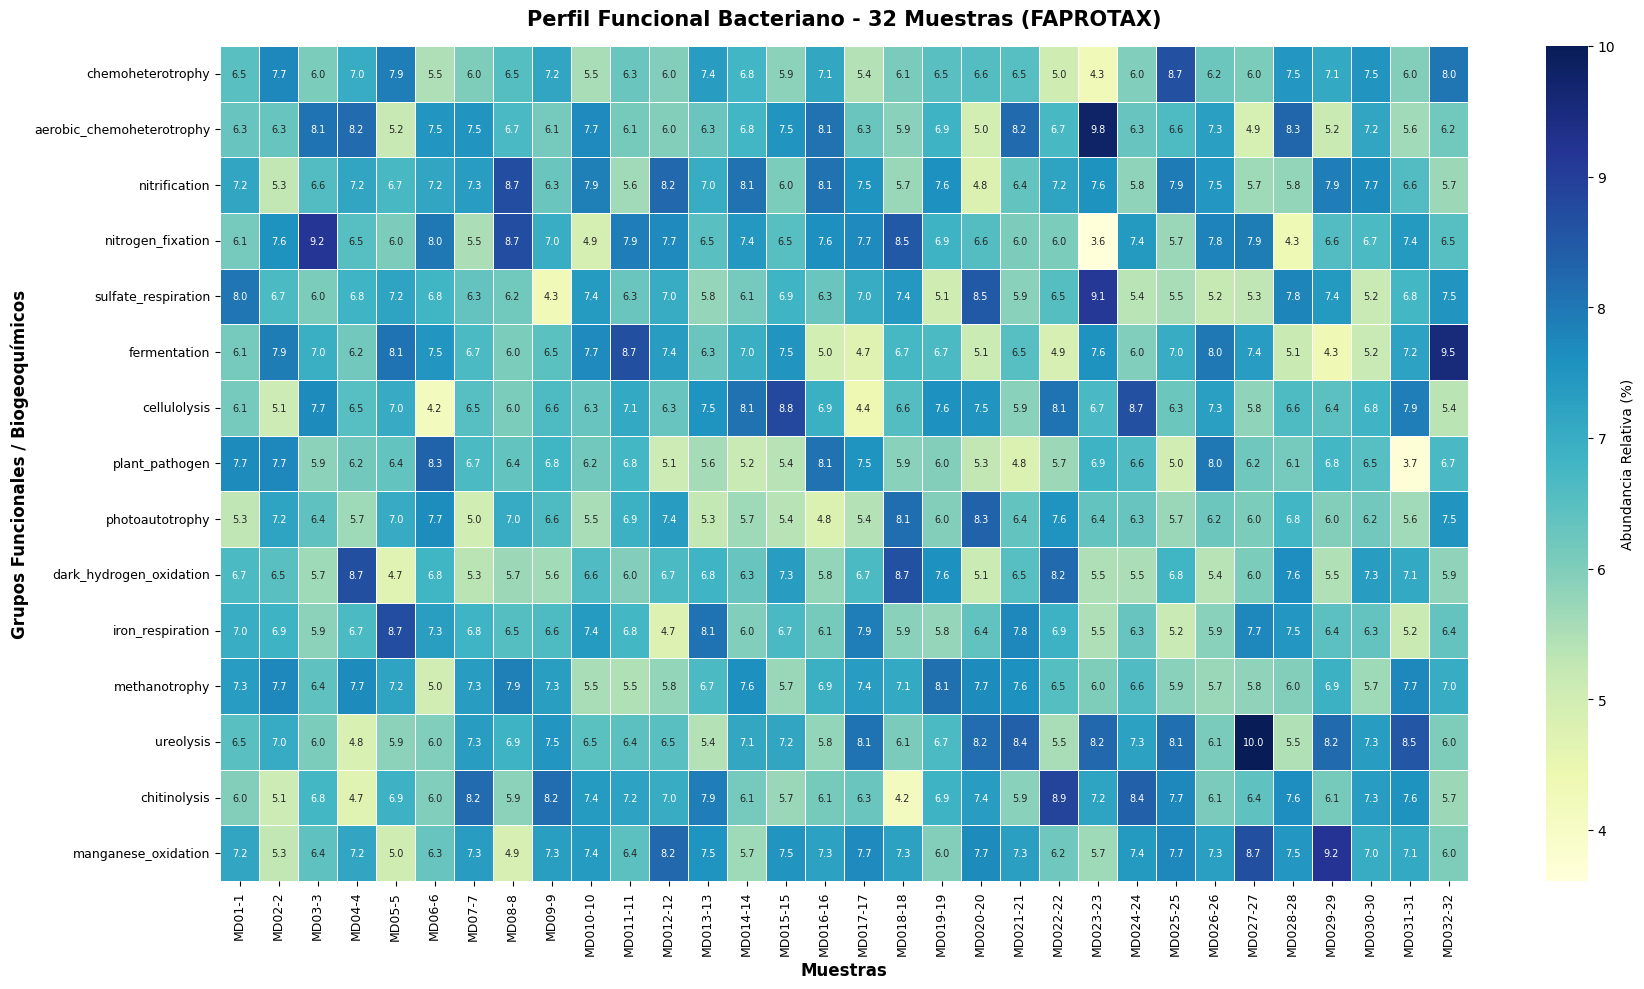

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's test generating a heatmap with 32 samples and 15 functions to verify dimensions and readability
np.random.seed(42)
sample_funcs = [
    'chemoheterotrophy', 'aerobic_chemoheterotrophy', 'nitrification',
    'nitrogen_fixation', 'sulfate_respiration', 'fermentation',
    'cellulolysis', 'plant_pathogen', 'photoautotrophy', 'dark_hydrogen_oxidation',
    'iron_respiration', 'methanotrophy', 'ureolysis', 'chitinolysis', 'manganese_oxidation'
]
data = np.random.poisson(lam=40, size=(len(sample_funcs), 32))
df_test = pd.DataFrame(data, index=sample_funcs, columns=sorted_samples)
df_rel_test = df_test.div(df_test.sum(axis=0), axis=1) * 100

plt.figure(figsize=(18, 10))
sns.heatmap(
    df_rel_test,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Abundancia Relativa (%)'},
    annot=True,
    fmt='.1f',
    annot_kws={"size": 7}
)
plt.title('Perfil Funcional Bacteriano - 32 Muestras (FAPROTAX)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Muestras', fontsize=12, fontweight='bold')
plt.ylabel('Grupos Funcionales / Biogeoquímicos', fontsize=12, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('faprotax_32_samples_heatmap.png', dpi=300)
print("32-sample Heatmap rendered successfully.")

Limpieza de muestras merge y procesamiento para la obtención de tabla feature y secuencias representativas

In [11]:
%%bash
set -e

# ------------------------------------------------------------------
# CONFIGURACIÓN DE PARÁMETROS AJUSTADOS
# ------------------------------------------------------------------
MIN_LEN=400          # Longitud mínima esperada para amplicón V3-V4
MAX_LEN=470          # Longitud máxima esperada
MAX_EE=1.0           # Umbral de Error Esperado (retiene ~67% de lecturas)
OTU_ID=0.97          # Identidad del 97% para agrupamiento de OTUs
THREADS=4            # Número de hilos/núcleos a usar

# Directorios de trabajo
OUT_DIR="./vsearch_output"
mkdir -p ${OUT_DIR}/filtered ${OUT_DIR}/derep

echo "=========================================================="
echo " PASO 1: Filtrado por Calidad de Muestras ya Unas (Merged)"
echo "=========================================================="

# Lista de las primeras 16 muestras
SAMPLES=("MD01-1" "MD02-2" "MD03-3" "MD04-4" "MD05-5" "MD06-6" "MD07-7" "MD08-8" \
         "MD09-9" "MD010-10" "MD011-11" "MD012-12" "MD013-13" "MD014-14" "MD015-15" "MD016-16")

for SAMPLE in "${SAMPLES[@]}"; do
    echo "Procesando muestra: ${SAMPLE}..."

    # 1.1 Filtrado por calidad EE <= 1.0 y etiquetas para VSEARCH
    # Asume que los archivos ${SAMPLE}_merged.fastq ya existen en /content/
    vsearch --fastq_filter /content/${SAMPLE}_merged.fastq \
            --fastq_maxee ${MAX_EE} \
            --fastq_minlen ${MIN_LEN} \
            --fastq_maxlen ${MAX_LEN} \
            --fastaout ${OUT_DIR}/filtered/${SAMPLE}.filtered.fasta \
            --relabel "${SAMPLE}." \
            --threads ${THREADS}
done

echo -e "\n=========================================================="
echo " PASO 2: Combinación y Dereplicación Global"
echo "=========================================================="

# Combinar todas las lecturas filtradas en un solo archivo
cat ${OUT_DIR}/filtered/*.fasta > ${OUT_DIR}/all_samples_combined.fasta

# Dereplicación global
vsearch --derep_fulllength ${OUT_DIR}/all_samples_combined.fasta \
        --output ${OUT_DIR}/derep/uniques.fasta \
        --sizeout \
        --minuniquesize 2 \
        --threads ${THREADS}

echo -e "\n=========================================================="
echo " PASO 3: Agrupamiento de OTUs (97%) y Remoción de Quimeras"
echo "=========================================================="

# 3.1 Clustering de OTUs al 97%,
vsearch --cluster_size ${OUT_DIR}/derep/uniques.fasta \
        --id ${OTU_ID} \
        --centroids ${OUT_DIR}/otus_raw.fasta \
        --threads ${THREADS}

# 3.2 Detección y eliminación de quimeras De Novo (UCHIME3)
vsearch --uchime3_denovo ${OUT_DIR}/otus_raw.fasta \
        --nonchimeras ${OUT_DIR}/otus.fasta \
        --relabel "OTU"

echo -e "\n=========================================================="
echo " PASO 4: Generación de la Tabla de Características (.tsv)"
echo "=========================================================="

# Mapear todas las lecturas filtradas contra las OTUs finales
vsearch --usearch_global ${OUT_DIR}/all_samples_combined.fasta \
        --db ${OUT_DIR}/otus.fasta \
        --id ${OTU_ID} \
        --otutabout ${OUT_DIR}/feature_table_picrust2.tsv \
        --threads ${THREADS}

echo -e "\n🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!"
echo "Archivos listos para PICRUSt2:"
echo "  1. Tabla de características: ${OUT_DIR}/feature_table_picrust2.tsv"
echo "  2. Secuencias representativas: ${OUT_DIR}/otus.fasta"

 PASO 1: Filtrado por Calidad de Muestras ya Unas (Merged)
Procesando muestra: MD01-1...
Procesando muestra: MD02-2...
Procesando muestra: MD03-3...
Procesando muestra: MD04-4...
Procesando muestra: MD05-5...
Procesando muestra: MD06-6...
Procesando muestra: MD07-7...
Procesando muestra: MD08-8...
Procesando muestra: MD09-9...
Procesando muestra: MD010-10...
Procesando muestra: MD011-11...
Procesando muestra: MD012-12...
Procesando muestra: MD013-13...
Procesando muestra: MD014-14...
Procesando muestra: MD015-15...
Procesando muestra: MD016-16...

 PASO 2: Combinación y Dereplicación Global

 PASO 3: Agrupamiento de OTUs (97%) y Remoción de Quimeras

 PASO 4: Generación de la Tabla de Características (.tsv)

🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!
Archivos listos para PICRUSt2:
  1. Tabla de características: ./vsearch_output/feature_table_picrust2.tsv
  2. Secuencias representativas: ./vsearch_output/otus.fasta


Only 1 thread used.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
33921 sequences kept (of which 0 truncated), 22934 sequences discarded.
Only 1 thread used.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
26768 sequences kept (of which 0 truncated), 19995 sequences discarded.
Only 1 thread used.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
31776 sequences kept (of which 0 truncated), 24247 sequences discarded.
Only 1 thread used.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
34693 sequences kept (of which 0 truncated), 24586 sequences discarded.
Only 1 thread used.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
24526 sequences kept (of which 0 truncated), 19661 sequen

In [12]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn

Instalación de Conda y Picrust2

In [3]:
import os
import sys

# Eliminar cualquier instalación previa o directorios de salida para un comienzo limpio
if os.path.exists('/content/picrust2_local'):
    !rm -rf /content/picrust2_local
if os.path.exists('picrust2_output'):
    !rm -rf picrust2_output

# 1. Instalar Miniconda
print("Instalando Miniconda...")
MINICONDA_INSTALLER_SCRIPT = "Miniconda3-latest-Linux-x86_64.sh"
MINICONDA_PREFIX = "/usr/local/conda"
!wget -q https://repo.anaconda.com/miniconda/$MINICONDA_INSTALLER_SCRIPT
!bash $MINICONDA_INSTALLER_SCRIPT -b -f -p $MINICONDA_PREFIX

# Configurar Conda y añadirlo al PATH para la sesión actual
print("Configurando Conda...")
# Se necesita agregar el bin de Conda al PATH del sistema para que los comandos de Conda funcionen
# y para que `conda run` pueda encontrar las utilidades.
sys.path.append(f"{MINICONDA_PREFIX}/lib/python3.9/site-packages")
os.environ["PATH"] = f"{MINICONDA_PREFIX}/bin:" + os.environ["PATH"]
!conda config --set auto_activate_base false # Prevenir la auto-activación del entorno base

# Aceptar los Términos de Servicio de Conda para los canales necesarios
print("Aceptando los Términos de Servicio de Conda...")
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

# Actualizar el entorno base de Conda
print("Actualizando Conda...")
!conda update -n base -c defaults conda -y

# 2. Instalar PICRUSt2 y sus dependencias (hmmer, epa-ng) usando Conda
print("Instalando PICRUSt2 y sus dependencias con Conda...")
CONDA_ENV_NAME = "picrust2_env"
# Crear el entorno
!conda create -n {CONDA_ENV_NAME} python=3.9 -y

# Instalar picrust2 en el nuevo entorno. Conda gestionará las dependencias como hmmer y epa-ng.
!conda install -n {CONDA_ENV_NAME} -c bioconda -c conda-forge picrust2 -y

# Verificar la instalación de Conda y PICRUSt2
print("Verificando instalación de Conda y PICRUSt2...")
!conda --version
!conda run -n {CONDA_ENV_NAME} which picrust2_pipeline.py

print("Ejecutando el pipeline de PICRUSt2. Esto puede tardar varios minutos...")
# Ahora ejecuta el pipeline de picrust2 usando el entorno Conda
!conda run -n {CONDA_ENV_NAME} picrust2_pipeline.py \
  -s /content/vsearch_output/otus.fasta \
  -i /content/vsearch_output/feature_table_picrust2.tsv \
  -o picrust2_output \
  -p 4 \
  --in_traits KO,EC,pathways

Instalando Miniconda...
PREFIX=/usr/local/conda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/conda
Configurando Conda...
WARNING conda.cli.condarc:set_key(484): Key auto_activate_base is an alias of auto_activate; setting value with latter
Aceptando los Términos de Servicio de Conda...
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Actualizando Conda...
Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: li

Ejecución de Picrust2

In [4]:
import pandas as pd

df_pwy = pd.read_csv('path_abun_unstrat.tsv', sep='\t')
sample_cols = ['MD01', 'MD010', 'MD011', 'MD012', 'MD013', 'MD014', 'MD015', 'MD016', 'MD02', 'MD03', 'MD04', 'MD05', 'MD06', 'MD07', 'MD08', 'MD09']
df_pwy['mean_abun'] = df_pwy[sample_cols].mean(axis=1)
top15_pwys = df_pwy.sort_values(by='mean_abun', ascending=False).head(15)['pathway'].tolist()

print("Top 15 PWY IDs:")
for p in top15_pwys:
    print(p)

Top 15 PWY IDs:
PWY-3781
PWY-7111
PWY-5101
ILEUSYN-PWY
VALSYN-PWY
BRANCHED-CHAIN-AA-SYN-PWY
PWY-5103
NONOXIPENT-PWY
PWY-6969
PWY-7094
TCA
PWY-5973
PWY-5667
PWY0-1319
PHOSLIPSYN-PWY


In [5]:
# Dictionary of MetaCyc Pathway IDs to Names for common PICRUSt2 pathways
metacyc_dict = {
    'PWY-3781': 'Respiración aeróbica I (citocromo c)',
    'PWY-7111': 'Síntesis de piruvato / Fermentación de piruvato',
    'PWY-5101': 'Biosíntesis de L-isoleucina II',
    'VALSYN-PWY': 'Biosíntesis de L-valina',
    'ILEUSYN-PWY': 'Biosíntesis de L-isoleucina I',
    'BRANCHED-CHAIN-AA-SYN-PWY': 'Biosíntesis de aminoácidos de cadena ramificada',
    'PWY-5103': 'Biosíntesis de L-isoleucina III',
    'NONOXIPENT-PWY': 'Vía de las pentosas fosfato (fase no oxidativa)',
    'PWY-6969': 'Biosíntesis de TCA / Ciclo del ácido cítrico',
    'PWY-7094': 'Biosíntesis de ácidos grasos (elongación)',
    'TCA': 'Ciclo del ácido tricarboxílico (Ciclo de Krebs)',
    'PWY-5973': 'Biosíntesis de cis-vacenato (ácidos grasos)',
    'PWY-5667': 'Biosíntesis de CDP-diacilglicerol I',
    'PWY0-1319': 'Biosíntesis de CDP-diacilglicerol II',
    'PHOSLIPSYN-PWY': 'Biosíntesis de fosfolípidos',
    '1CMET2-PWY': 'Biosíntesis de THF / Metabolismo de 1 carbono',
    '3-HYDROXYPHENYLACETATE-DEGRADATION-PWY': 'Degradación de 3-hidroxifenilacetato',
    'AEROBACTINSYN-PWY': 'Biosíntesis de aerobactina',
    'ALL-CHORISMATE-PWY': 'Supervía de biosíntesis de corismato'
}

for pwy in top15_pwys:
    desc = metacyc_dict.get(pwy, pwy)
    print(f"'{pwy}': '{pwy} ({desc})'")

'PWY-3781': 'PWY-3781 (Respiración aeróbica I (citocromo c))'
'PWY-7111': 'PWY-7111 (Síntesis de piruvato / Fermentación de piruvato)'
'PWY-5101': 'PWY-5101 (Biosíntesis de L-isoleucina II)'
'ILEUSYN-PWY': 'ILEUSYN-PWY (Biosíntesis de L-isoleucina I)'
'VALSYN-PWY': 'VALSYN-PWY (Biosíntesis de L-valina)'
'BRANCHED-CHAIN-AA-SYN-PWY': 'BRANCHED-CHAIN-AA-SYN-PWY (Biosíntesis de aminoácidos de cadena ramificada)'
'PWY-5103': 'PWY-5103 (Biosíntesis de L-isoleucina III)'
'NONOXIPENT-PWY': 'NONOXIPENT-PWY (Vía de las pentosas fosfato (fase no oxidativa))'
'PWY-6969': 'PWY-6969 (Biosíntesis de TCA / Ciclo del ácido cítrico)'
'PWY-7094': 'PWY-7094 (Biosíntesis de ácidos grasos (elongación))'
'TCA': 'TCA (Ciclo del ácido tricarboxílico (Ciclo de Krebs))'
'PWY-5973': 'PWY-5973 (Biosíntesis de cis-vacenato (ácidos grasos))'
'PWY-5667': 'PWY-5667 (Biosíntesis de CDP-diacilglicerol I)'
'PWY0-1319': 'PWY0-1319 (Biosíntesis de CDP-diacilglicerol II)'
'PHOSLIPSYN-PWY': 'PHOSLIPSYN-PWY (Biosíntesis de fo

In [11]:
import pandas as pd

df_pwy = pd.read_csv('path_abun_unstrat.tsv', sep='\t')
df_otu = pd.read_csv('otu_taxa_table.bacterias.xls - otu_taxa_table.xls.tsv', sep='\t')

print("PWY cols:", df_pwy.columns.tolist())
print("OTU cols:", df_otu.columns.tolist())

PWY cols: ['pathway', 'MD01', 'MD010', 'MD011', 'MD012', 'MD013', 'MD014', 'MD015', 'MD016', 'MD02', 'MD03', 'MD04', 'MD05', 'MD06', 'MD07', 'MD08', 'MD09']
OTU cols: ['OTU_ID', 'MD01-1', 'MD02-2', 'MD03-3', 'MD04-4', 'MD05-5', 'MD06-6', 'MD07-7', 'MD08-8', 'MD09-9', 'MD10-10', 'MD11-11', 'MD12-12', 'MD13-13', 'MD14-14', 'MD15-15', 'MD16-16', 'taxonomy']


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Read files
df_pwy = pd.read_csv('path_abun_unstrat.tsv', sep='\t')
df_otu = pd.read_csv('otu_taxa_table.bacterias.xls - otu_taxa_table.xls.tsv', sep='\t')

# Mapping sample names: PWY -> OTU format (MD01-1, MD02-2, ..., MD16-16)
mapping = {
    'MD01': 'MD01-1', 'MD02': 'MD02-2', 'MD03': 'MD03-3', 'MD04': 'MD04-4',
    'MD05': 'MD05-5', 'MD06': 'MD06-6', 'MD07': 'MD07-7', 'MD08': 'MD08-8',
    'MD09': 'MD09-9', 'MD010': 'MD10-10', 'MD011': 'MD11-11', 'MD012': 'MD12-12',
    'MD013': 'MD13-13', 'MD014': 'MD14-14', 'MD015': 'MD15-15', 'MD016': 'MD16-16'
}

df_pwy_renamed = df_pwy.rename(columns=mapping)

sample_cols = ['MD01-1', 'MD02-2', 'MD03-3', 'MD04-4', 'MD05-5', 'MD06-6', 'MD07-7', 'MD08-8',
               'MD09-9', 'MD10-10', 'MD11-11', 'MD12-12', 'MD13-13', 'MD14-14', 'MD15-15', 'MD16-16']

# Clean taxonomy
def extract_clean_taxon(tax_str):
    if pd.isna(tax_str):
        return "Unclassified"
    parts = tax_str.split(';')
    for p in reversed(parts):
        p_strip = p.strip()
        if p_strip.startswith('g__') and len(p_strip) > 3:
            return p_strip.replace('g__', '')
        elif p_strip.startswith('f__') and len(p_strip) > 3:
            return "f_" + p_strip.replace('f__', '')
        elif p_strip.startswith('o__') and len(p_strip) > 3:
            return "o_" + p_strip.replace('o__', '')
    return parts[-1].strip()

df_otu['Taxon'] = df_otu['taxonomy'].apply(extract_clean_taxon) + " (" + df_otu['OTU_ID'] + ")"

df_pwy_mat = df_pwy_renamed.set_index('pathway')[sample_cols]
df_otu_mat = df_otu.set_index('Taxon')[sample_cols]

top_pwy = df_pwy_mat.mean(axis=1).nlargest(15).index
top_tax = df_otu_mat.mean(axis=1).nlargest(15).index

df_pwy_top = df_pwy_mat.loc[top_pwy]
df_tax_top = df_otu_mat.loc[top_tax]

# Dict for MetaCyc names
metacyc_dict = {
    'PWY-3781': 'PWY-3781 (Respiración aeróbica I)',
    'PWY-7111': 'PWY-7111 (Síntesis/Fermentación de piruvato)',
    'PWY-5101': 'PWY-5101 (Biosíntesis de L-isoleucina II)',
    'VALSYN-PWY': 'VALSYN-PWY (Biosíntesis de L-valina)',
    'ILEUSYN-PWY': 'ILEUSYN-PWY (Biosíntesis de L-isoleucina I)',
    'BRANCHED-CHAIN-AA-SYN-PWY': 'BRANCHED-CHAIN-AA-SYN-PWY (Biosíntesis AA cadena ramificada)',
    'PWY-5103': 'PWY-5103 (Biosíntesis de L-isoleucina III)',
    'NONOXIPENT-PWY': 'NONOXIPENT-PWY (Vía pentosas fosfato - no oxidativa)',
    'PWY-6969': 'PWY-6969 (Iniciación TCA / Ácido cítrico)',
    'PWY-7094': 'PWY-7094 (Biosíntesis de ácidos grasos)',
    'TCA': 'TCA (Ciclo del ácido tricarboxílico)',
    'PWY-5973': 'PWY-5973 (Biosíntesis de cis-vacenato)',
    'PWY-5667': 'PWY-5667 (Biosíntesis de CDP-diacilglicerol I)',
    'PWY0-1319': 'PWY0-1319 (Biosíntesis de CDP-diacilglicerol II)',
    'PHOSLIPSYN-PWY': 'PHOSLIPSYN-PWY (Biosíntesis de fosfolípidos)'
}

corr_matrix = pd.DataFrame(index=top_pwy, columns=top_tax, dtype=float)
p_matrix = pd.DataFrame(index=top_pwy, columns=top_tax, dtype=float)

for pwy in top_pwy:
    for tax in top_tax:
        rho, pval = spearmanr(df_pwy_top.loc[pwy], df_tax_top.loc[tax])
        corr_matrix.loc[pwy, tax] = rho
        p_matrix.loc[pwy, tax] = pval

corr_matrix_labeled = corr_matrix.rename(index=metacyc_dict)

# Annotation matrix showing Spearman coefficient 'r = ...' or 'r = ...*'
annot_matrix = pd.DataFrame("", index=corr_matrix_labeled.index, columns=top_tax)
for pwy in top_pwy:
    pwy_label = metacyc_dict.get(pwy, pwy)
    for tax in top_tax:
        pval = p_matrix.loc[pwy, tax]
        rho = corr_matrix.loc[pwy, tax]
        if pval < 0.01:
            annot_matrix.loc[pwy_label, tax] = f"r={rho:.2f}**"
        elif pval < 0.05:
            annot_matrix.loc[pwy_label, tax] = f"r={rho:.2f}*"
        else:
            annot_matrix.loc[pwy_label, tax] = f"r={rho:.2f}"

# Plot without TOP 15 in title and with clear Spearman r coefficients
plt.figure(figsize=(16, 11))
sns.heatmap(
    corr_matrix_labeled,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Coeficiente de Correlación de Spearman (r)"}
)

# Title without TOP 15
plt.title("Correlación de Spearman entre Rutas Metabólicas y Taxones (OTUs)\nA través de las muestras (MD01-1 a MD16-16)\n(* p < 0.05, ** p < 0.01)", fontsize=13, weight='bold', pad=15)
plt.xlabel("Taxón / OTU", fontsize=11, labelpad=10)
plt.ylabel("Vía Metabólica (MetaCyc Pathway)", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.savefig("spearman_no_top15.png", dpi=300)
plt.close()
print("Generated heatmap successfully without TOP 15 in header!")

Generated heatmap successfully without TOP 15 in header!


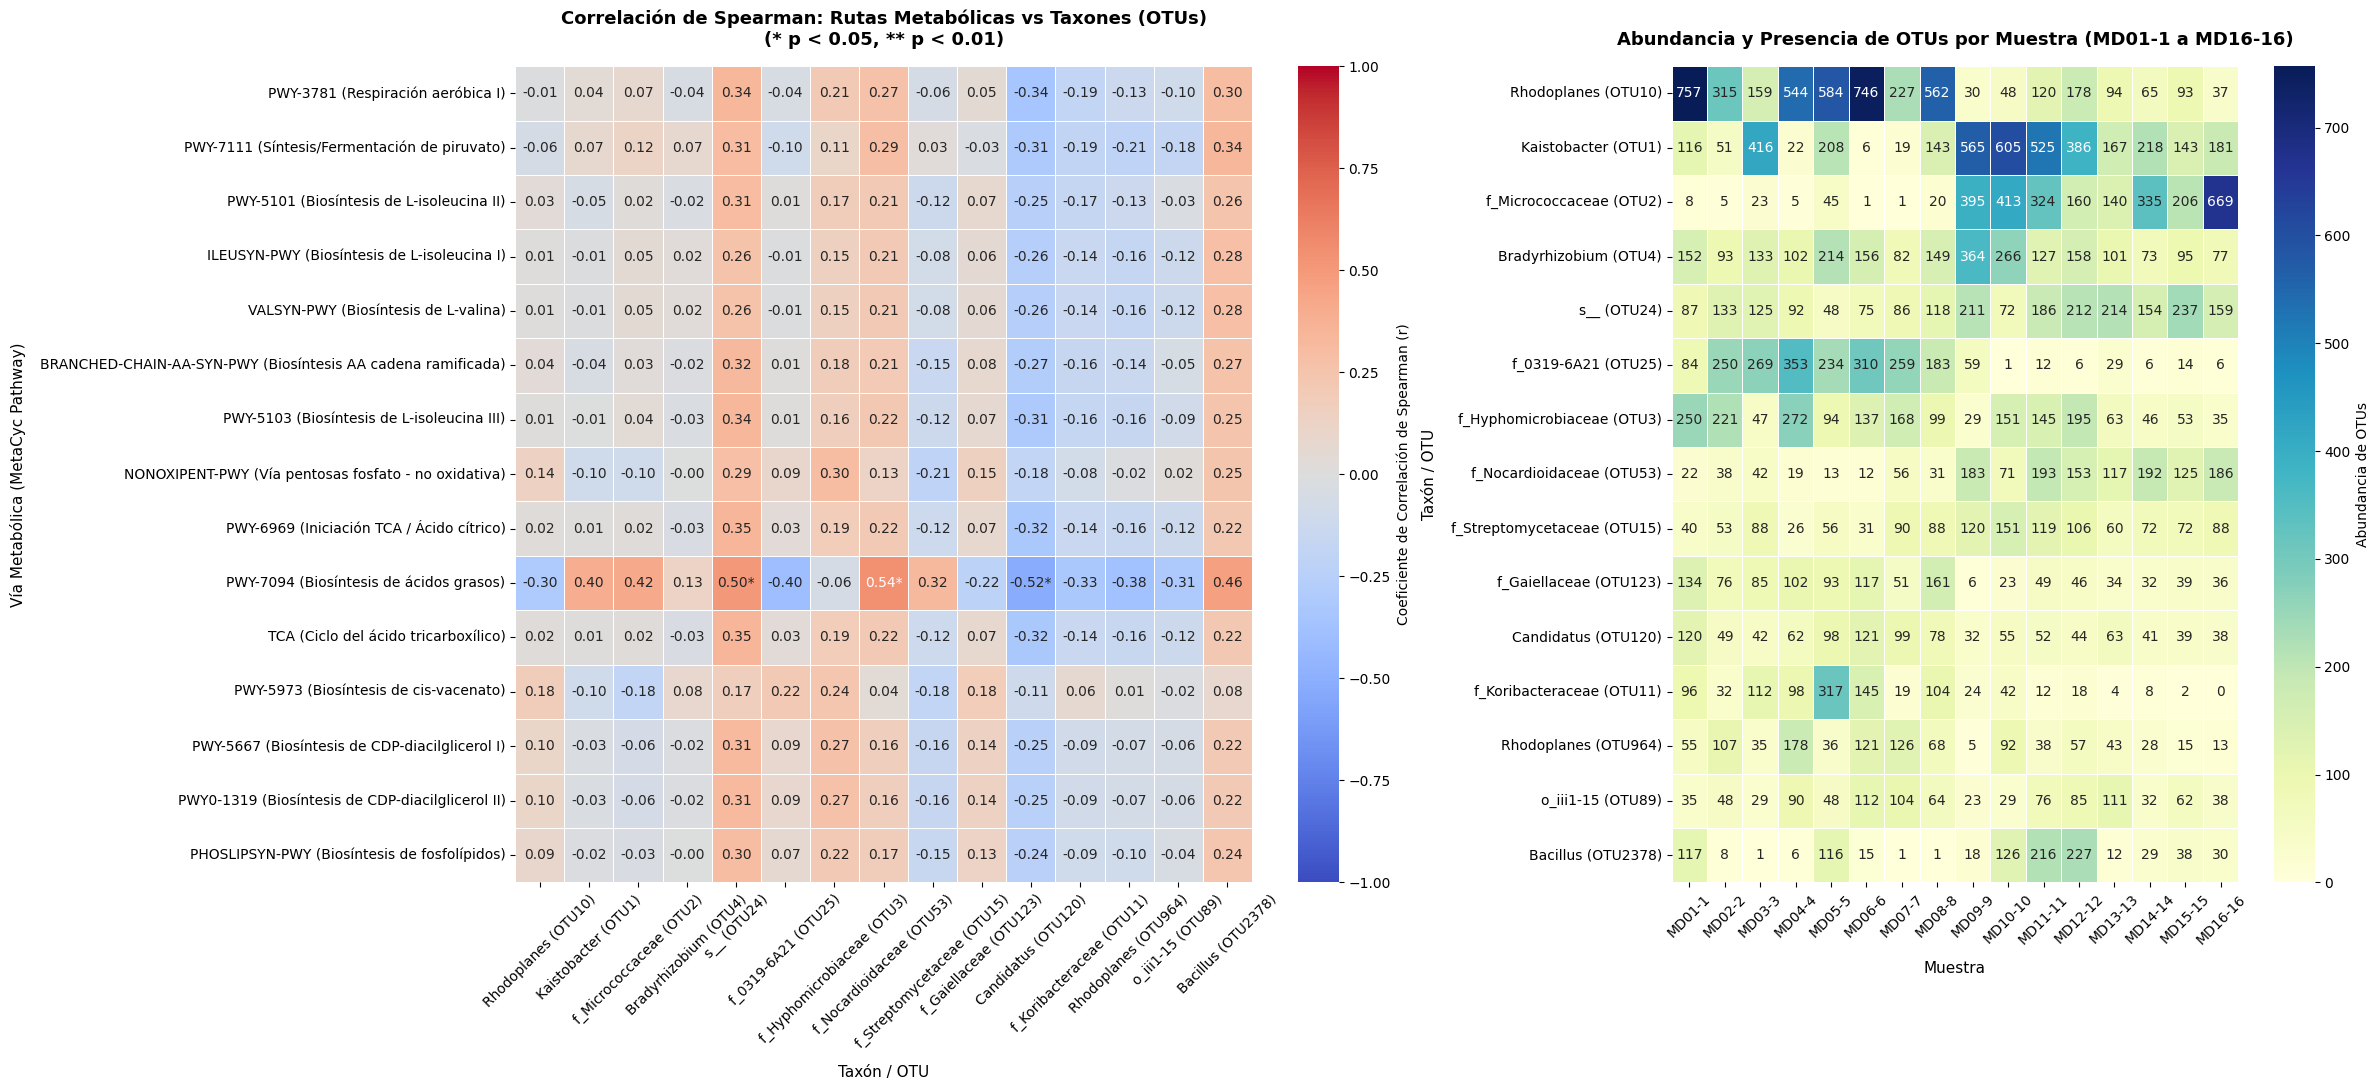

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

# ======================================================================
# 1. CARGA DE DATOS Y HOMOLOGACIÓN DE MUESTRAS (MD01-1 a MD16-16)
# ======================================================================
df_pwy = pd.read_csv('path_abun_unstrat.tsv', sep='\t')
df_otu = pd.read_csv(
    'otu_taxa_table.bacterias.xls - otu_taxa_table.xls.tsv', sep='\t'
)

# Mapeo de muestras para homologar al formato MD0-0
mapping = {
    'MD01': 'MD01-1',
    'MD02': 'MD02-2',
    'MD03': 'MD03-3',
    'MD04': 'MD04-4',
    'MD05': 'MD05-5',
    'MD06': 'MD06-6',
    'MD07': 'MD07-7',
    'MD08': 'MD08-8',
    'MD09': 'MD09-9',
    'MD010': 'MD10-10',
    'MD011': 'MD11-11',
    'MD012': 'MD12-12',
    'MD013': 'MD13-13',
    'MD014': 'MD14-14',
    'MD015': 'MD15-15',
    'MD016': 'MD16-16',
}

df_pwy_renamed = df_pwy.rename(columns=mapping)

sample_cols = [
    'MD01-1',
    'MD02-2',
    'MD03-3',
    'MD04-4',
    'MD05-5',
    'MD06-6',
    'MD07-7',
    'MD08-8',
    'MD09-9',
    'MD10-10',
    'MD11-11',
    'MD12-12',
    'MD13-13',
    'MD14-14',
    'MD15-15',
    'MD16-16',
]

# ======================================================================
# 2. DICCIONARIO METACYC Y LIMPIEZA DE TAXONOMÍA
# ======================================================================
metacyc_dict = {
    'PWY-3781': 'PWY-3781 (Respiración aeróbica I)',
    'PWY-7111': 'PWY-7111 (Síntesis/Fermentación de piruvato)',
    'PWY-5101': 'PWY-5101 (Biosíntesis de L-isoleucina II)',
    'VALSYN-PWY': 'VALSYN-PWY (Biosíntesis de L-valina)',
    'ILEUSYN-PWY': 'ILEUSYN-PWY (Biosíntesis de L-isoleucina I)',
    'BRANCHED-CHAIN-AA-SYN-PWY': (
        'BRANCHED-CHAIN-AA-SYN-PWY (Biosíntesis AA cadena ramificada)'
    ),
    'PWY-5103': 'PWY-5103 (Biosíntesis de L-isoleucina III)',
    'NONOXIPENT-PWY': 'NONOXIPENT-PWY (Vía pentosas fosfato - no oxidativa)',
    'PWY-6969': 'PWY-6969 (Iniciación TCA / Ácido cítrico)',
    'PWY-7094': 'PWY-7094 (Biosíntesis de ácidos grasos)',
    'TCA': 'TCA (Ciclo del ácido tricarboxílico)',
    'PWY-5973': 'PWY-5973 (Biosíntesis de cis-vacenato)',
    'PWY-5667': 'PWY-5667 (Biosíntesis de CDP-diacilglicerol I)',
    'PWY0-1319': 'PWY0-1319 (Biosíntesis de CDP-diacilglicerol II)',
    'PHOSLIPSYN-PWY': 'PHOSLIPSYN-PWY (Biosíntesis de fosfolípidos)',
}


def extract_clean_taxon(tax_str):
  if pd.isna(tax_str):
    return 'Unclassified'
  parts = tax_str.split(';')
  for p in reversed(parts):
    p_strip = p.strip()
    if p_strip.startswith('g__') and len(p_strip) > 3:
      return p_strip.replace('g__', '')
    elif p_strip.startswith('f__') and len(p_strip) > 3:
      return 'f_' + p_strip.replace('f__', '')
    elif p_strip.startswith('o__') and len(p_strip) > 3:
      return 'o_' + p_strip.replace('o__', '')
  return parts[-1].strip()


df_otu['Taxon'] = (
    df_otu['taxonomy'].apply(extract_clean_taxon) + ' (' + df_otu['OTU_ID'] + ')'
)

# Definir matrices
df_pwy_mat = df_pwy_renamed.set_index('pathway')[sample_cols]
df_otu_mat = df_otu.set_index('Taxon')[sample_cols]

# Selección de los elementos principales
top_pwy = df_pwy_mat.mean(axis=1).nlargest(15).index
top_tax = df_otu_mat.mean(axis=1).nlargest(15).index

df_pwy_top = df_pwy_mat.loc[top_pwy]
df_tax_top = df_otu_mat.loc[top_tax]

# ======================================================================
# 3. CORRELACIÓN DE SPEARMAN (SÓLO NÚMEROS Y ASTERISCOS, SIN "r=")
# ======================================================================
corr_matrix = pd.DataFrame(index=top_pwy, columns=top_tax, dtype=float)
p_matrix = pd.DataFrame(index=top_pwy, columns=top_tax, dtype=float)

for pwy in top_pwy:
  for tax in top_tax:
    rho, pval = spearmanr(df_pwy_top.loc[pwy], df_tax_top.loc[tax])
    corr_matrix.loc[pwy, tax] = rho
    p_matrix.loc[pwy, tax] = pval

corr_matrix_labeled = corr_matrix.rename(index=metacyc_dict)

# Formato numérico limpio: sólo el valor y la significancia
annot_matrix = pd.DataFrame("", index=corr_matrix_labeled.index, columns=top_tax)
for pwy in top_pwy:
  pwy_label = metacyc_dict.get(pwy, pwy)
  for tax in top_tax:
    pval = p_matrix.loc[pwy, tax]
    rho = corr_matrix.loc[pwy, tax]
    if pval < 0.01:
      annot_matrix.loc[pwy_label, tax] = f"{rho:.2f}**"
    elif pval < 0.05:
      annot_matrix.loc[pwy_label, tax] = f"{rho:.2f}*"
    else:
      annot_matrix.loc[pwy_label, tax] = f"{rho:.2f}"

# ======================================================================
# 4. TABLA DE ABUNDANCIA DE OTUS EN LAS MUESTRAS
# ======================================================================
df_tax_sample_abun = df_tax_top[sample_cols]

# ======================================================================
# 5. GRAFICACIÓN PANEL DOBLE
# ======================================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(24, 11), gridspec_kw={'width_ratios': [1.3, 1]}
)

# Panel Izquierdo: Correlación de Spearman
sns.heatmap(
    corr_matrix_labeled,
    annot=annot_matrix,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación de Spearman (r)'},
    ax=ax1,
)
ax1.set_title(
    'Correlación de Spearman: Rutas Metabólicas vs Taxones (OTUs)\n(* p < 0.05,'
    ' ** p < 0.01)',
    fontsize=13,
    weight='bold',
    pad=15,
)
ax1.set_xlabel('Taxón / OTU', fontsize=11, labelpad=10)
ax1.set_ylabel('Vía Metabólica (MetaCyc Pathway)', fontsize=11, labelpad=10)
ax1.tick_params(axis='x', rotation=45)

# Panel Derecho: Relación OTUs vs Muestras (MD01-1 a MD16-16)
sns.heatmap(
    df_tax_sample_abun,
    annot=True,
    fmt='g',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Abundancia de OTUs'},
    ax=ax2,
)
ax2.set_title(
    'Abundancia y Presencia de OTUs por Muestra (MD01-1 a MD16-16)',
    fontsize=13,
    weight='bold',
    pad=15,
)
ax2.set_xlabel('Muestra', fontsize=11, labelpad=10)
ax2.set_ylabel('Taxón / OTU', fontsize=11, labelpad=10)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('spearman_y_abundancia_muestras.png', dpi=300)
plt.show()